In [ ]:
import pandas as pd
import os

# Define the base directory where files are located
BASE = "/content"

# File paths (corrected to point directly to files in /content/)
file_paths = {
    "TCN_model_search_lagged": os.path.join(BASE, "TCN_model_search_lagged_18-03-2025-12-22-20.csv"),
    "TCN_new_model": os.path.join(BASE, "TCN_new_model_26-11-2024-00-40-59.csv"),
    "TCN_new_model_search": os.path.join(BASE, "TCN_new_model_search_26-11-2024-00-27-43.csv")
}

# Load the CSV files
dataframes = {name: pd.read_csv(path) for name, path in file_paths.items()}

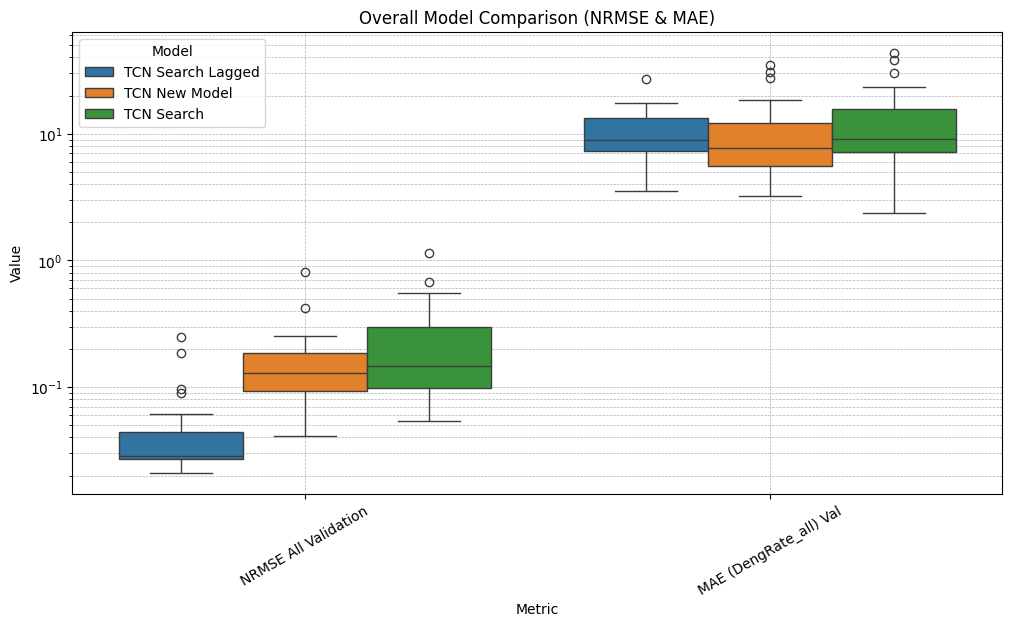

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rename keys for readability
model_names = {
    "TCN_model_search_lagged": "TCN Search Lagged",
    "TCN_new_model": "TCN New Model",
    "TCN_new_model_search": "TCN Search",
}

# Prepare data for visualization
metric_cols = ["NRMSE All Validation", "MAE (DengRate_all) Val"]
merged_data = []

for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Overall Comparison: Boxplots of Metrics Across Models
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="Metric", y="Value", hue="Model")
plt.yscale("log")  # Log scale for better visibility
plt.title("Overall Model Comparison (NRMSE & MAE)")
plt.xticks(rotation=30)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/

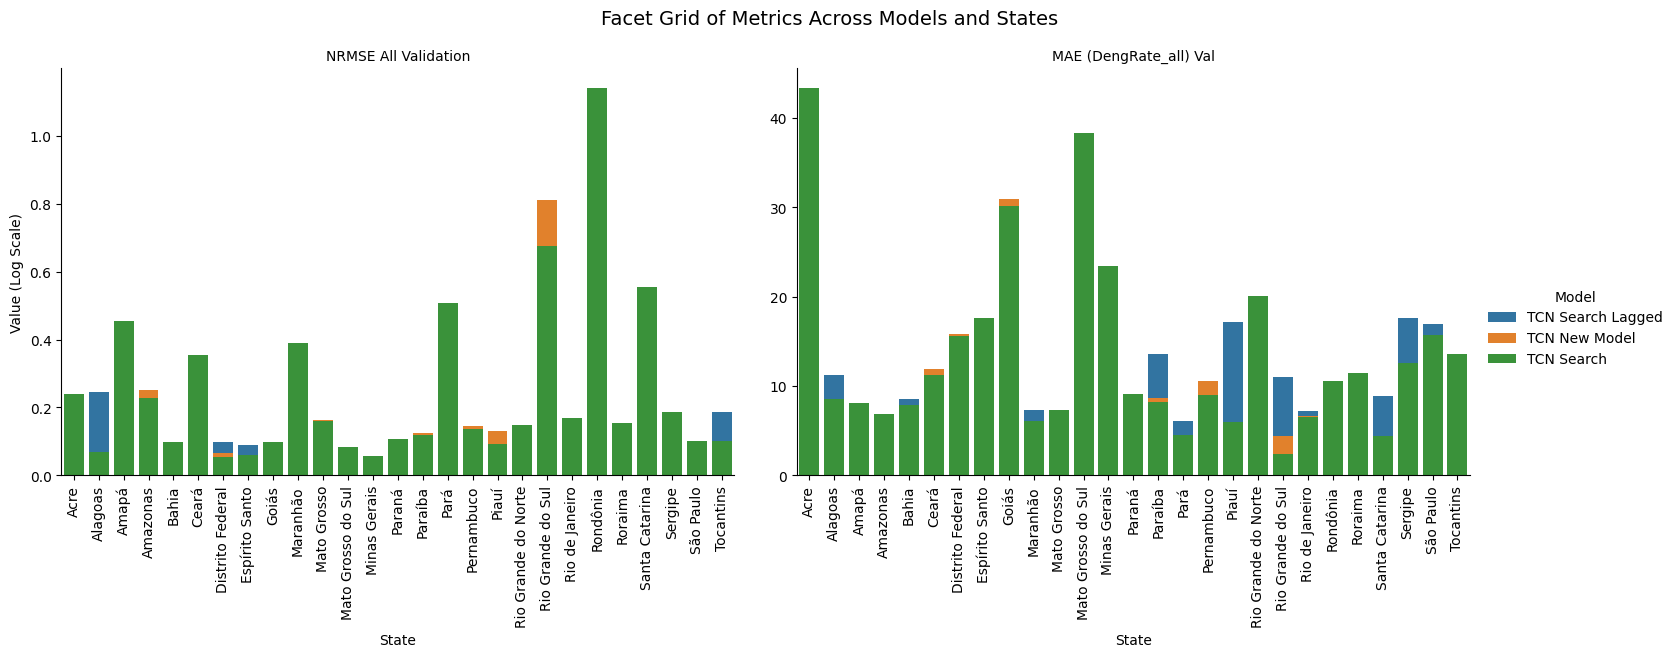

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# FacetGrid for small multiples
g = sns.FacetGrid(df_plot, col="Metric", hue="Model", sharey=False, height=5, aspect=1.5)
g.map(sns.barplot, "State", "Value", order=sorted(df_plot["State"].unique()), ci=None)
g.set_xticklabels(rotation=90)
g.set_ylabels("Value (Log Scale)")
g.set_titles(col_template="{col_name}")
g.add_legend()

plt.suptitle("Facet Grid of Metrics Across Models and States", y=1.05, fontsize=14)
plt.show()


/tmp/ipykernel_7406/3408420473.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_plot, x="State", y="Value", hue="Model", ci=None)


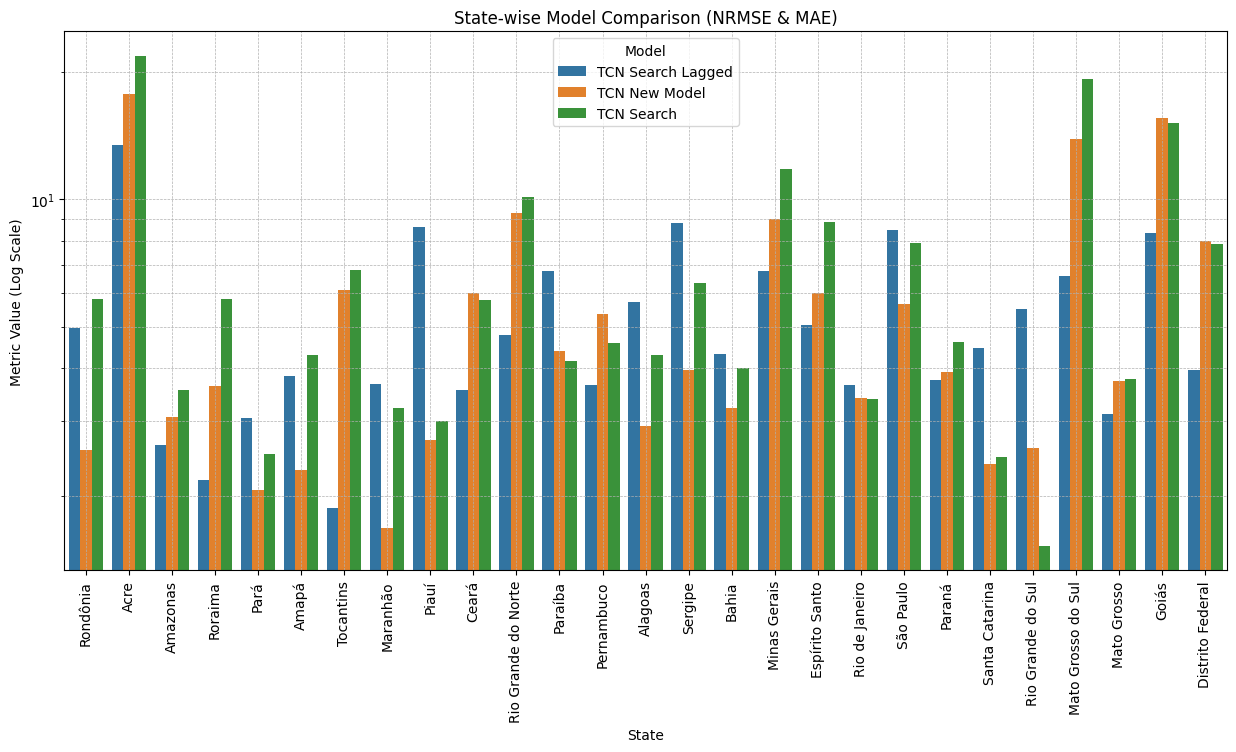

In [ ]:
# Re-prepare the data for visualization
merged_data = []
for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Single visualization for all states
plt.figure(figsize=(15, 7))
sns.barplot(data=df_plot, x="State", y="Value", hue="Model", ci=None)
plt.yscale("log")  # Log scale for better visibility
plt.xticks(rotation=90)
plt.title("State-wise Model Comparison (NRMSE & MAE)")
plt.xlabel("State")
plt.ylabel("Metric Value (Log Scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Model")
plt.show()


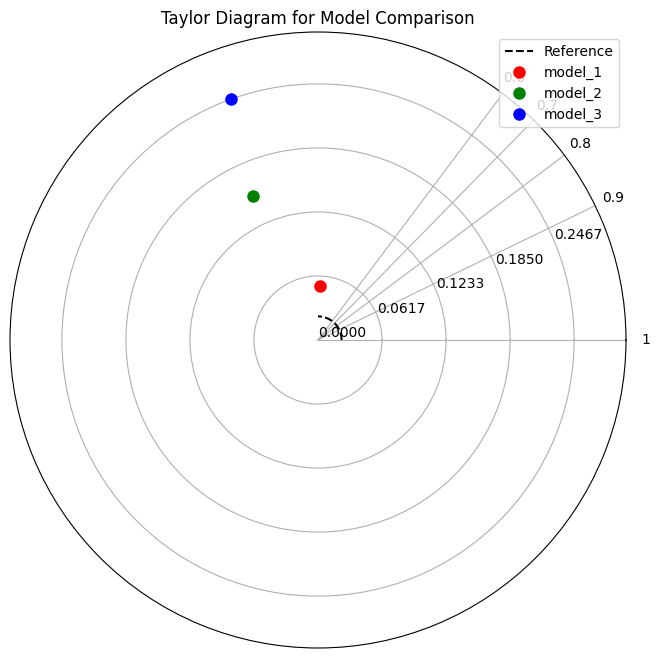

In [1]:
import pandas as pd
import numpy as np
import math
import os
import matplotlib.pyplot as plt

# =========================
# BASE DIRECTORY
# =========================
BASE = os.getcwd()   # current working directory

# =========================
# FILE PATHS (FIXED)
# =========================
file_paths = {
    "model_1": os.path.join(BASE, "TCN_model_search_lagged_18-03-2025-12-22-20.csv"),
    "model_2": os.path.join(BASE, "TCN_new_model_26-11-2024-00-40-59.csv"),
    "model_3": os.path.join(BASE, "TCN_new_model_search_26-11-2024-00-27-43.csv"),
    "actual_data": os.path.join(BASE, "merged_dataset.csv")
}

# =========================
# TAYLOR FUNCTION
# =========================
def plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    angles = np.arccos(correlations)

    theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(theta, [ref_std] * 100, "k--", label="Reference")

    for i, label in enumerate(labels):
        ax.plot(angles[i], std_devs[i], "o", label=label, color=colors[i], markersize=8)

    ax.set_xticks(np.arccos([1, 0.9, 0.8, 0.7, 0.6]))
    ax.set_xticklabels(["1", "0.9", "0.8", "0.7", "0.6"])
    ax.set_ylim(0, max(std_devs) + 0.05)
    ax.set_yticks(np.linspace(0, max(std_devs), 5))

    plt.legend(loc="upper right")
    plt.title("Taylor Diagram for Model Comparison")
    plt.show()

# =========================
# LOAD DATA
# =========================
datasets = {key: pd.read_csv(path) for key, path in file_paths.items()}

# =========================
# DEPARTMENT MAPPING
# =========================
DEP_NAMES = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro',
    35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul',
    51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# =========================
# PROCESS
# =========================
actual_data = datasets["actual_data"].copy()
actual_data["Department"] = actual_data["dep_id"].map(DEP_NAMES)

actual_avg = actual_data.groupby("Department")[["DengRate_all", "DengRate_019"]].mean().reset_index()

merged_datasets = {}
for model_name, model_df in datasets.items():
    if model_name != "actual_data":
        merged_datasets[model_name] = model_df.merge(actual_avg, on="Department", how="left")

# =========================
# COMPUTE STATS
# =========================
model_stats = {}

for model_name, df in merged_datasets.items():
    nrmse = df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna()
    actual = df["DengRate_all"].dropna()

    common_idx = nrmse.index.intersection(actual.index)

    std_dev = nrmse.loc[common_idx].std()
    correlation = np.corrcoef(nrmse.loc[common_idx], actual.loc[common_idx])[0, 1]

    model_stats[model_name] = {
        "std_dev": std_dev,
        "correlation": correlation
    }

# =========================
# PREPARE PLOT
# =========================
labels = list(model_stats.keys())
std_devs = np.array([model_stats[m]["std_dev"] for m in labels])
correlations = np.array([model_stats[m]["correlation"] for m in labels])
ref_std = actual_avg["DengRate_all"].std()

# =========================
# PLOT
# =========================
plot_taylor_diagram(std_devs, correlations, ref_std, labels, ["r", "g", "b"])

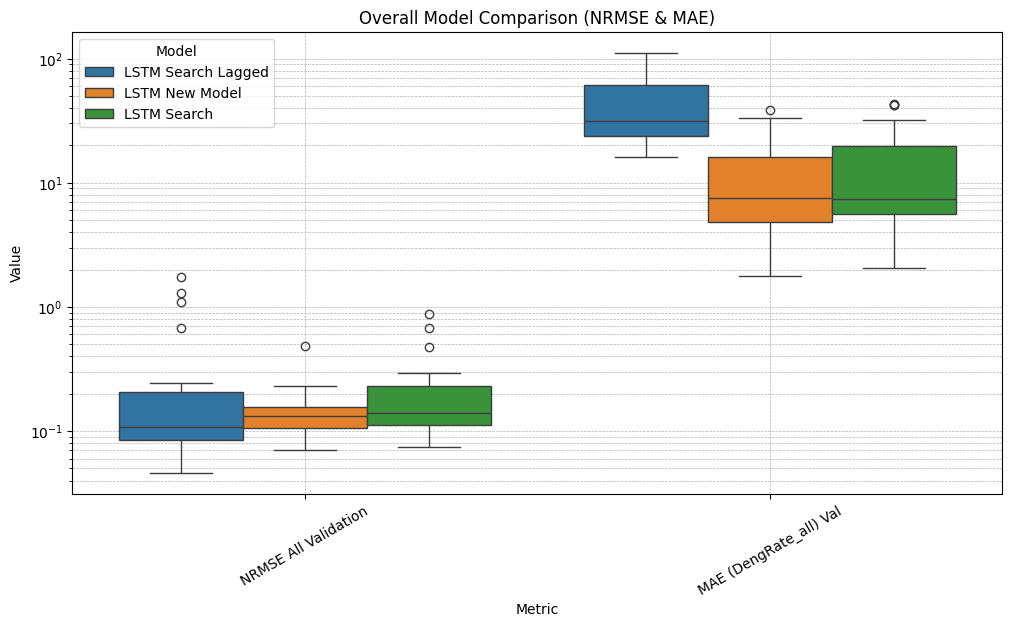

/tmp/ipykernel_7406/1381048920.py:69: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_plot, x="State", y="Value", hue="Model", ci=None)


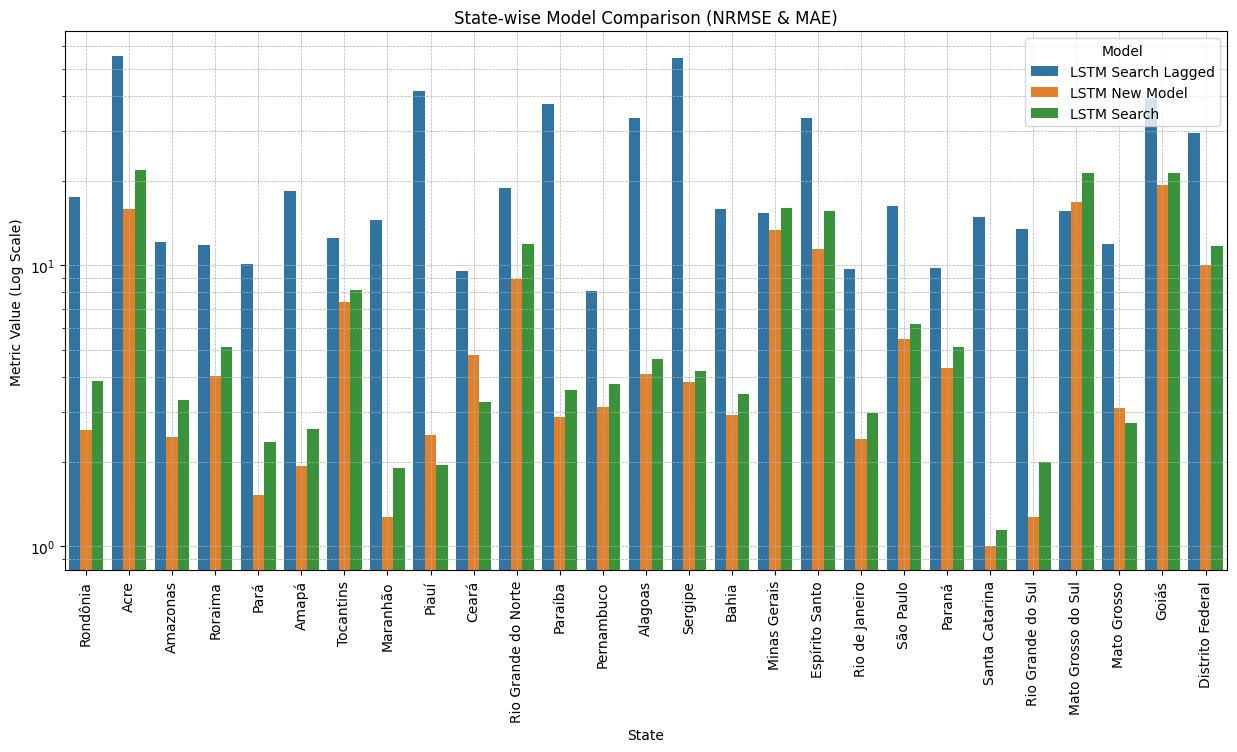

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/

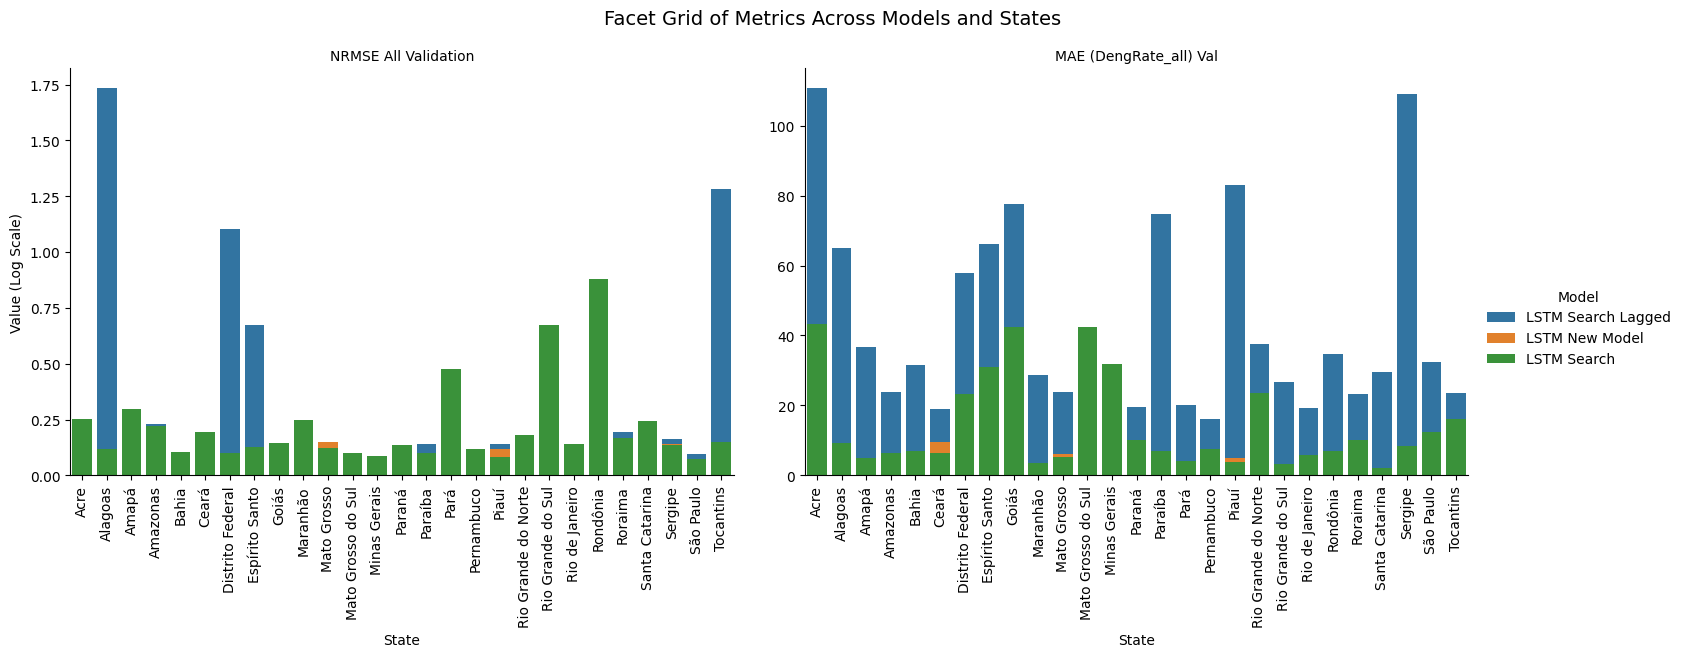

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os module for path handling

# Define the base directory where files are located
BASE = "/content"

# File paths (corrected to point directly to files in /content/)
file_paths = {
    "LSTM_Model_search_lagged": os.path.join(BASE, "LSTM_Model_search_lagged_18-03-2025-20-16-03.csv"),
    "LSTM_new_Model": os.path.join(BASE, "LSTM_Model_26-11-2024-00-46-12.csv"),
    "LSTM_new_Model_search": os.path.join(BASE, "LSTM_Model_search_26-11-2024-00-44-37.csv"),
}

# Load the CSV files
dataframes = {name: pd.read_csv(path) for name, path in file_paths.items()}
# Rename keys for readability
model_names = {
    "LSTM_Model_search_lagged": "LSTM Search Lagged",
    "LSTM_new_Model": "LSTM New Model",
    "LSTM_new_Model_search": "LSTM Search",
}

# Prepare data for visualization
metric_cols = ["NRMSE All Validation", "MAE (DengRate_all) Val"]
merged_data = []

for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Overall Comparison: Boxplots of Metrics Across Models
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="Metric", y="Value", hue="Model")
plt.yscale("log")  # Log scale for better visibility
plt.title("Overall Model Comparison (NRMSE & MAE)")
plt.xticks(rotation=30)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# Re-prepare the data for visualization
merged_data = []
for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Single visualization for all states
plt.figure(figsize=(15, 7))
sns.barplot(data=df_plot, x="State", y="Value", hue="Model", ci=None)
plt.yscale("log")  # Log scale for better visibility
plt.xticks(rotation=90)
plt.title("State-wise Model Comparison (NRMSE & MAE)")
plt.xlabel("State")
plt.ylabel("Metric Value (Log Scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Model")
plt.show()

# FacetGrid for small multiples
g = sns.FacetGrid(df_plot, col="Metric", hue="Model", sharey=False, height=5, aspect=1.5)
g.map(sns.barplot, "State", "Value", order=sorted(df_plot["State"].unique()), ci=None)
g.set_xticklabels(rotation=90)
g.set_ylabels("Value (Log Scale)")
g.set_titles(col_template="{col_name}")
g.add_legend()

plt.suptitle("Facet Grid of Metrics Across Models and States", y=1.05, fontsize=14)
plt.show()

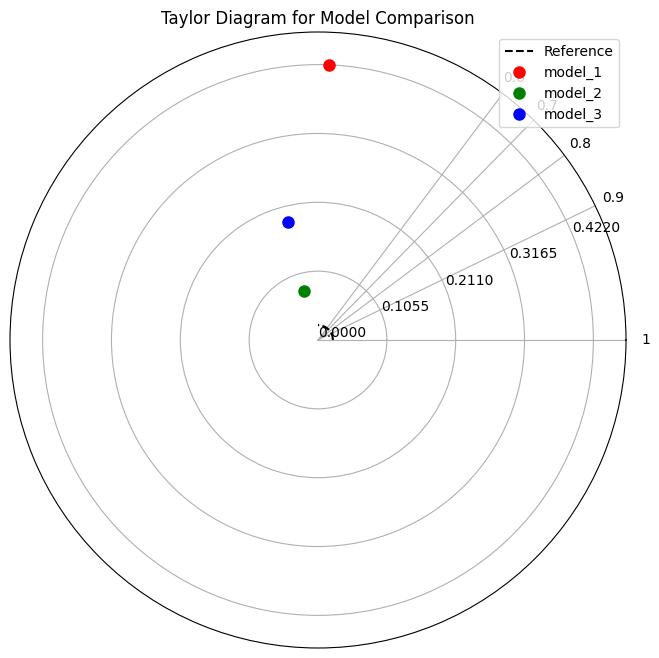

In [ ]:
import math
import pandas as pd # Added this import
import numpy as np # Added this import
import os # Added this import
import matplotlib.pyplot as plt # Added this import

# Reload the datasets
# Assuming all files are directly in /content/ based on file explorer output
file_paths = {
    "model_1": os.path.join("/content", "LSTM_Model_search_lagged_18-03-2025-20-16-03.csv"),
    "model_2": os.path.join("/content", "LSTM_Model_26-11-2024-00-46-12.csv"),
    "model_3": os.path.join("/content", "LSTM_Model_search_26-11-2024-00-44-37.csv"),
    "actual_data": os.path.join("/content", "merged_dataset.csv")
}

def plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors):
    """ Generate a Taylor Diagram manually using Matplotlib """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    # Convert correlation to angles (arccosine of correlation)
    angles = np.arccos(correlations)

    # Reference circle (actual standard deviation)
    theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(theta, [ref_std] * 100, "k--", label="Reference")

    # Plot each model's performance
    for i, label in enumerate(labels):
        ax.plot(angles[i], std_devs[i], "o", label=label, color=colors[i], markersize=8)

    # Configure polar plot
    ax.set_xticks(np.arccos([1, 0.9, 0.8, 0.7, 0.6]))  # Correlation markers
    ax.set_xticklabels(["1", "0.9", "0.8", "0.7", "0.6"])
    ax.set_ylim(0, max(std_devs) + 0.05)
    ax.set_yticks(np.linspace(0, max(std_devs), 5))

    # Labels and title
    plt.legend(loc="upper right")
    plt.title("Taylor Diagram for Model Comparison")
    plt.show()

# Load data into a dictionary
datasets = {key: pd.read_csv(path) for key, path in file_paths.items()}

# Mapping department IDs to names
DEP_NAMES = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro',
    35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul',
    51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# Map department IDs to names
actual_data = datasets["actual_data"].copy()
actual_data["Department"] = actual_data["dep_id"].map(DEP_NAMES)

# Compute average dengue rates per department
actual_avg = actual_data.groupby("Department")[["DengRate_all", "DengRate_019"]].mean().reset_index()

# Merge actual averages with model metric datasets
merged_datasets = {}
for model_name, model_df in datasets.items():
    if model_name != "actual_data":
        merged_datasets[model_name] = model_df.merge(actual_avg, on="Department", how="left")

# Compute statistics for Taylor diagram
model_stats = {}
for model_name, df in merged_datasets.items():
    std_dev = df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna().std()
    correlation = np.corrcoef(df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna(),
                              df["DengRate_all"].dropna())[0, 1]
    model_stats[model_name] = {"std_dev": std_dev, "correlation": correlation}

# Convert to arrays for plotting
labels = list(model_stats.keys())
std_devs = np.array([model_stats[m]["std_dev"] for m in labels])
correlations = np.array([model_stats[m]["correlation"] for m in labels])
ref_std = actual_avg["DengRate_all"].std()  # Reference standard deviation

# Plot Taylor diagram
plot_taylor_diagram(std_devs, correlations, ref_std, labels, ["r", "g", "b"])

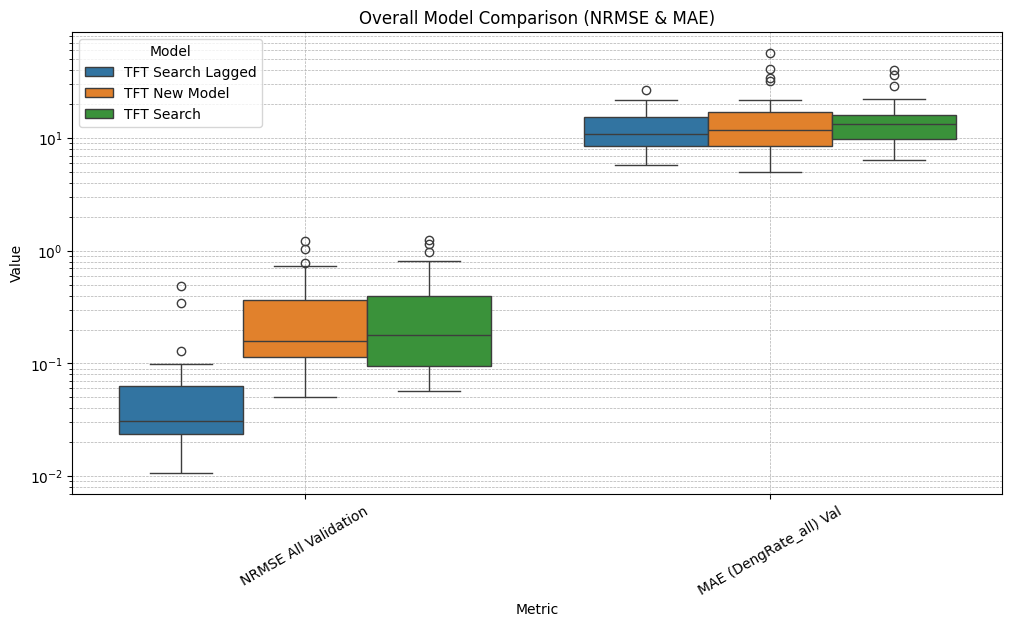

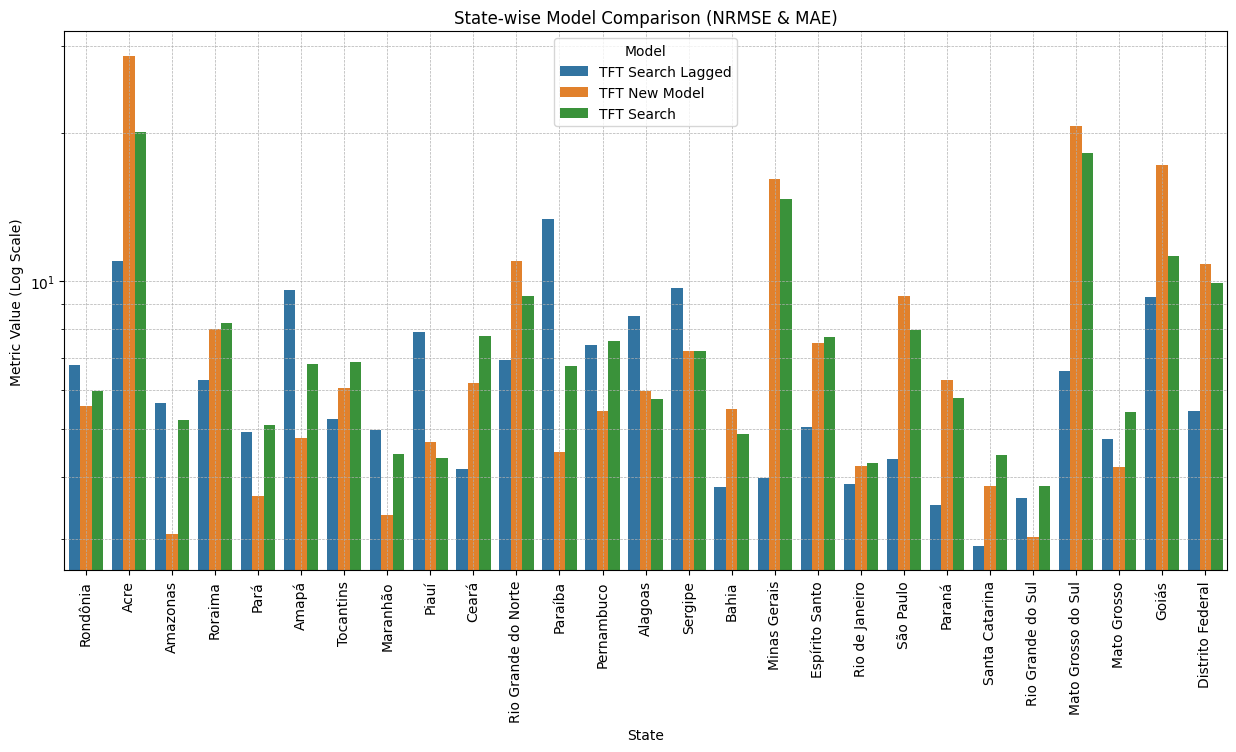

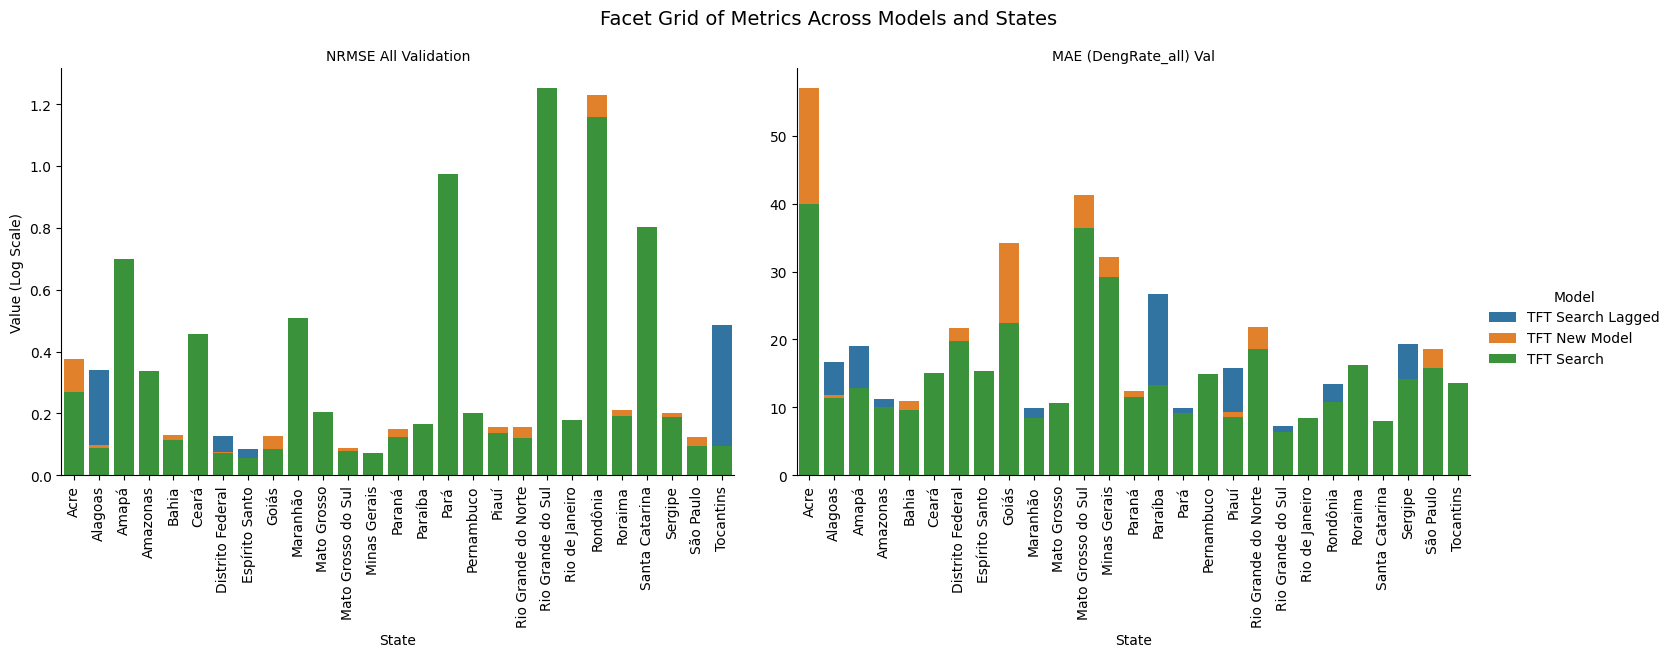

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added import for os

BASE = "/content"

file_paths = {
    "TFT_Model_search_lagged": os.path.join(BASE, "TFT_model_lagged_18-03-2025-22-51-57.csv"),
    "TFT_new_Model": os.path.join(BASE, "TFT_new_model_18-03-2025-23-03-37.csv"),
    "TFT_new_Model_search": os.path.join(BASE, "TFT_model_search_18-03-2025-22-58-39.csv"),
}

# Load the CSV files
dataframes = {name: pd.read_csv(path) for name, path in file_paths.items()}
# Rename keys for readability
model_names = {
    "TFT_Model_search_lagged": "TFT Search Lagged",
    "TFT_new_Model": "TFT New Model",
    "TFT_new_Model_search": "TFT Search",
}

# Prepare data for visualization
metric_cols = ["NRMSE All Validation", "MAE (DengRate_all) Val"]
merged_data = []

for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Overall Comparison: Boxplots of Metrics Across Models
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="Metric", y="Value", hue="Model")
plt.yscale("log")  # Log scale for better visibility
plt.title("Overall Model Comparison (NRMSE & MAE)")
plt.xticks(rotation=30)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# Re-prepare the data for visualization
merged_data = []
for model, df in dataframes.items():
    for metric in metric_cols:
        for _, row in df.iterrows():
            merged_data.append({
                "Model": model_names[model],
                "State": row["Department"],
                "Metric": metric,
                "Value": row[metric],
            })

# Convert to DataFrame
df_plot = pd.DataFrame(merged_data)

# Single visualization for all states
plt.figure(figsize=(15, 7))
sns.barplot(data=df_plot, x="State", y="Value", hue="Model", errorbar=None) # Changed ci to errorbar
plt.yscale("log")  # Log scale for better visibility
plt.xticks(rotation=90)
plt.title("State-wise Model Comparison (NRMSE & MAE)")
plt.xlabel("State")
plt.ylabel("Metric Value (Log Scale)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(title="Model")
plt.show()

# FacetGrid for small multiples
g = sns.FacetGrid(df_plot, col="Metric", hue="Model", sharey=False, height=5, aspect=1.5)
g.map(sns.barplot, "State", "Value", order=sorted(df_plot["State"].unique()), errorbar=None) # Changed ci to errorbar
g.set_xticklabels(rotation=90)
g.set_ylabels("Value (Log Scale)")
g.set_titles(col_template="{col_name}")
g.add_legend()

plt.suptitle("Facet Grid of Metrics Across Models and States", y=1.05, fontsize=14)
plt.show()

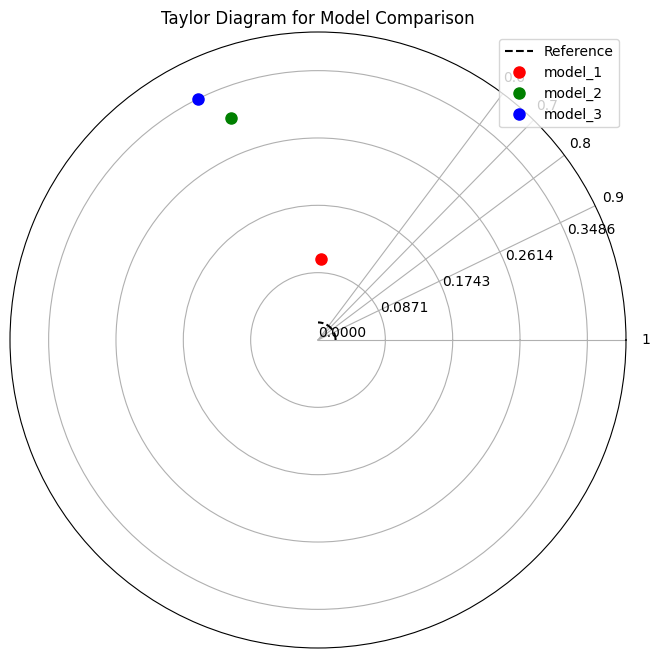

In [ ]:
import math
import pandas as pd # Added this import
import numpy as np # Added this import
import os # Added this import
import matplotlib.pyplot as plt # Added this import

# Reload the datasets
# Assuming all files are directly in /content/ based on file explorer output
file_paths = {
    "model_1": os.path.join("/content", "TFT_model_lagged_18-03-2025-22-51-57.csv"),
    "model_2": os.path.join("/content", "TFT_new_model_18-03-2025-23-03-37.csv"),
    "model_3": os.path.join("/content", "TFT_model_search_18-03-2025-22-58-39.csv"),
    "actual_data": os.path.join("/content", "merged_dataset.csv")
}

def plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors):
    """ Generate a Taylor Diagram manually using Matplotlib """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    # Convert correlation to angles (arccosine of correlation)
    angles = np.arccos(correlations)

    # Reference circle (actual standard deviation)
    theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(theta, [ref_std] * 100, "k--", label="Reference")

    # Plot each model's performance
    for i, label in enumerate(labels):
        ax.plot(angles[i], std_devs[i], "o", label=label, color=colors[i], markersize=8)

    # Configure polar plot
    ax.set_xticks(np.arccos([1, 0.9, 0.8, 0.7, 0.6]))  # Correlation markers
    ax.set_xticklabels(["1", "0.9", "0.8", "0.7", "0.6"])
    ax.set_ylim(0, max(std_devs) + 0.05)
    ax.set_yticks(np.linspace(0, max(std_devs), 5))

    # Labels and title
    plt.legend(loc="upper right")
    plt.title("Taylor Diagram for Model Comparison")
    plt.show()

# Load data into a dictionary
datasets = {key: pd.read_csv(path) for key, path in file_paths.items()}

# Mapping department IDs to names
DEP_NAMES = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro',
    35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul',
    51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# Map department IDs to names
actual_data = datasets["actual_data"].copy()
actual_data["Department"] = actual_data["dep_id"].map(DEP_NAMES)

# Compute average dengue rates per department
actual_avg = actual_data.groupby("Department")[["DengRate_all", "DengRate_019"]].mean().reset_index()

# Merge actual averages with model metric datasets
merged_datasets = {}
for model_name, model_df in datasets.items():
    if model_name != "actual_data":
        merged_datasets[model_name] = model_df.merge(actual_avg, on="Department", how="left")

# Compute statistics for Taylor diagram
model_stats = {}
for model_name, df in merged_datasets.items():
    std_dev = df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna().std()
    correlation = np.corrcoef(df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna(),
                              df["DengRate_all"].dropna())[0, 1]
    model_stats[model_name] = {"std_dev": std_dev, "correlation": correlation}

# Convert to arrays for plotting
labels = list(model_stats.keys())
std_devs = np.array([model_stats[m]["std_dev"] for m in labels])
correlations = np.array([model_stats[m]["correlation"] for m in labels])
ref_std = actual_avg["DengRate_all"].std()  # Reference standard deviation

# Plot Taylor diagram
plot_taylor_diagram(std_devs, correlations, ref_std, labels, ["r", "g", "b"])

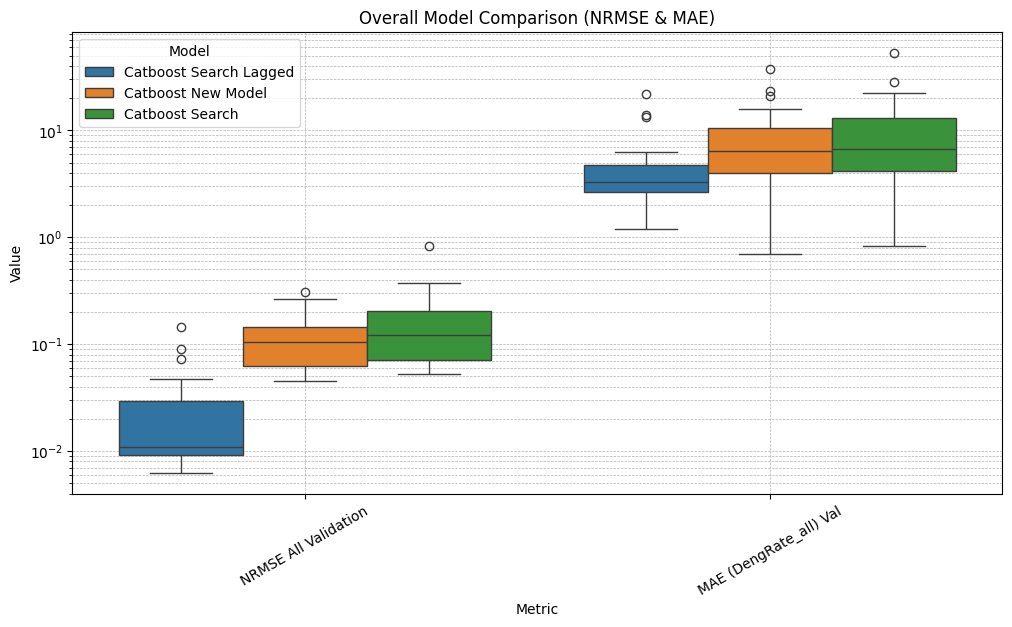

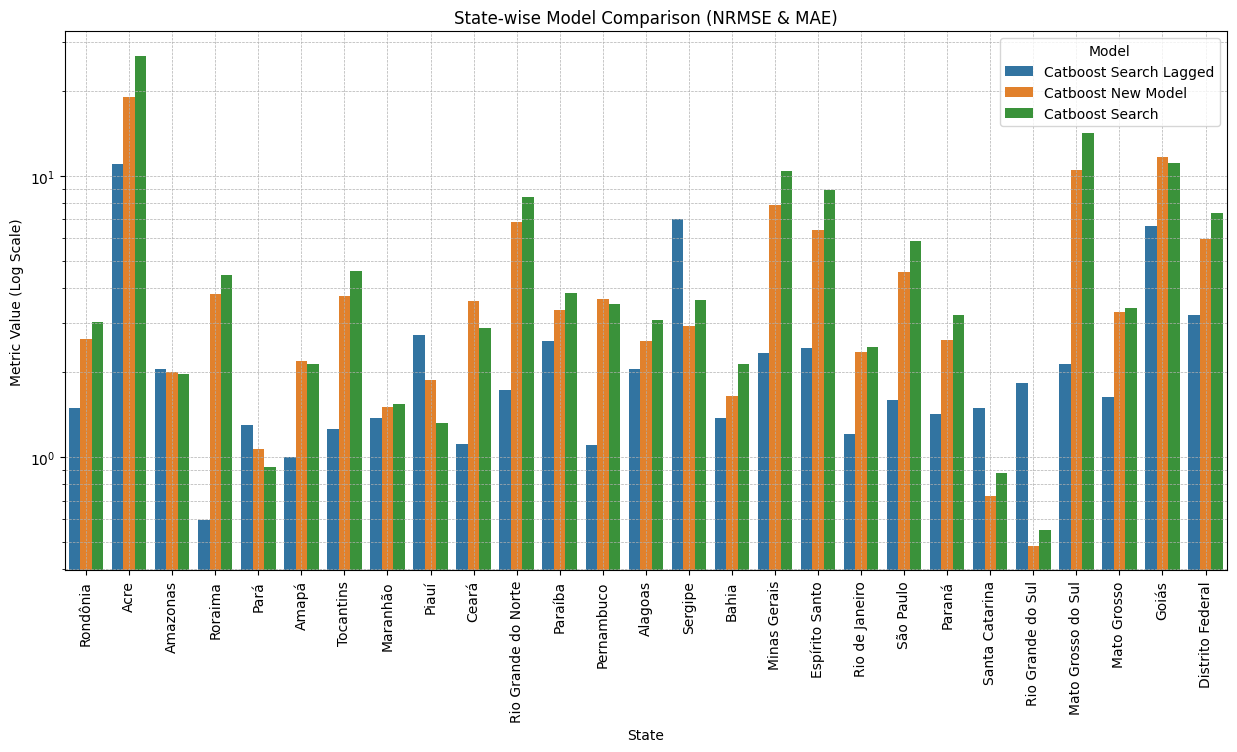

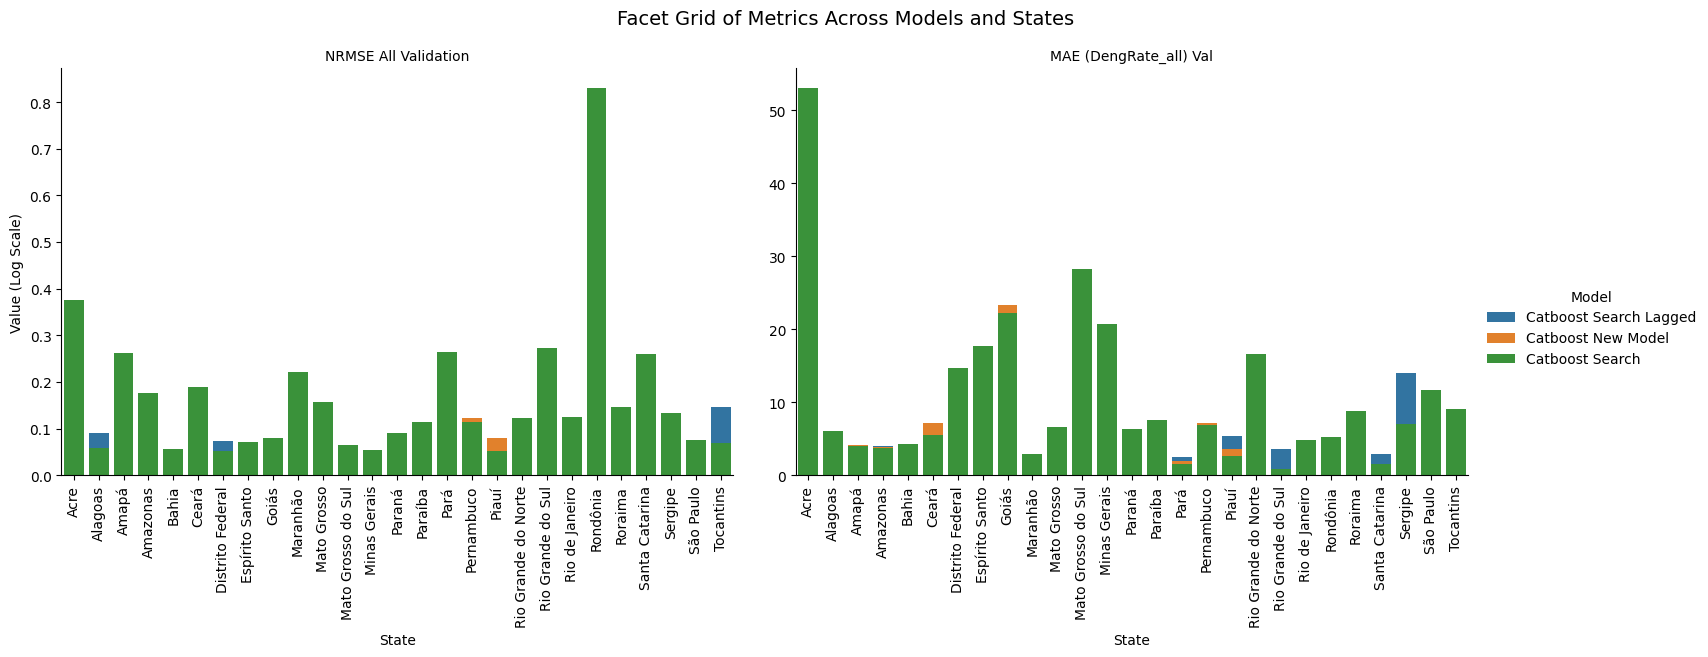

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = "/content"

file_paths = {
    "Catboost_Model_search_lagged": os.path.join(BASE, "catboost_lagged_19-03-2025-00-47-00.csv"),
    "Catboost_new_Model": os.path.join(BASE, "catboost_normal26-11-2024-01-03-19.csv"),
    "Catboost_new_Model_search": os.path.join(BASE, "catboost_search_26-11-2024-02-20-15.csv"),
}

# Load the CSV files, handling missing files gracefully
dataframes = {}
for name, path in file_paths.items():
    try:
        dataframes[name] = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Warning: File not found for {name} at {path}. Skipping this model.")

# Check if any dataframes were loaded
if not dataframes:
    print("Error: No Catboost model dataframes could be loaded. Cannot proceed with visualization.")
else:
    # Rename keys for readability
    model_names = {
        "Catboost_Model_search_lagged": "Catboost Search Lagged",
        "Catboost_new_Model": "Catboost New Model",
        "Catboost_new_Model_search": "Catboost Search",
    }

    # Filter model_names to include only successfully loaded dataframes
    available_model_names = {k: v for k, v in model_names.items() if k in dataframes}

    # Prepare data for visualization
    metric_cols = ["NRMSE All Validation", "MAE (DengRate_all) Val"]
    merged_data = []

    for model, df in dataframes.items():
        for metric in metric_cols:
            for _, row in df.iterrows():
                merged_data.append({
                    "Model": available_model_names[model],
                    "State": row["Department"],
                    "Metric": metric,
                    "Value": row[metric],
                })

    # Convert to DataFrame
    df_plot = pd.DataFrame(merged_data)

    # Overall Comparison: Boxplots of Metrics Across Models
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x="Metric", y="Value", hue="Model")
    plt.yscale("log")  # Log scale for better visibility
    plt.title("Overall Model Comparison (NRMSE & MAE)")
    plt.xticks(rotation=30)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

    # Re-prepare the data for visualization (this part is redundant if df_plot is already created correctly above, but kept for consistency with original cell structure)
    # It's better to reuse df_plot created earlier if dataframes are loaded only once
    # For now, let's keep it to ensure it processes only the available dataframes
    merged_data = []
    for model, df in dataframes.items():
        for metric in metric_cols:
            for _, row in df.iterrows():
                merged_data.append({
                    "Model": available_model_names[model],
                    "State": row["Department"],
                    "Metric": metric,
                    "Value": row[metric],
                })

    # Convert to DataFrame
    df_plot = pd.DataFrame(merged_data)

    # Single visualization for all states
    plt.figure(figsize=(15, 7))
    sns.barplot(data=df_plot, x="State", y="Value", hue="Model", errorbar=None) # Changed ci to errorbar
    plt.yscale("log")  # Log scale for better visibility
    plt.xticks(rotation=90)
    plt.title("State-wise Model Comparison (NRMSE & MAE)")
    plt.xlabel("State")
    plt.ylabel("Metric Value (Log Scale)")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(title="Model")
    plt.show()

    # FacetGrid for small multiples
    g = sns.FacetGrid(df_plot, col="Metric", hue="Model", sharey=False, height=5, aspect=1.5)
    g.map(sns.barplot, "State", "Value", order=sorted(df_plot["State"].unique()), errorbar=None) # Changed ci to errorbar
    g.set_xticklabels(rotation=90)
g.set_ylabels("Value (Log Scale)")
g.set_titles(col_template="{col_name}")
g.add_legend()

plt.suptitle("Facet Grid of Metrics Across Models and States", y=1.05, fontsize=14)
plt.show()

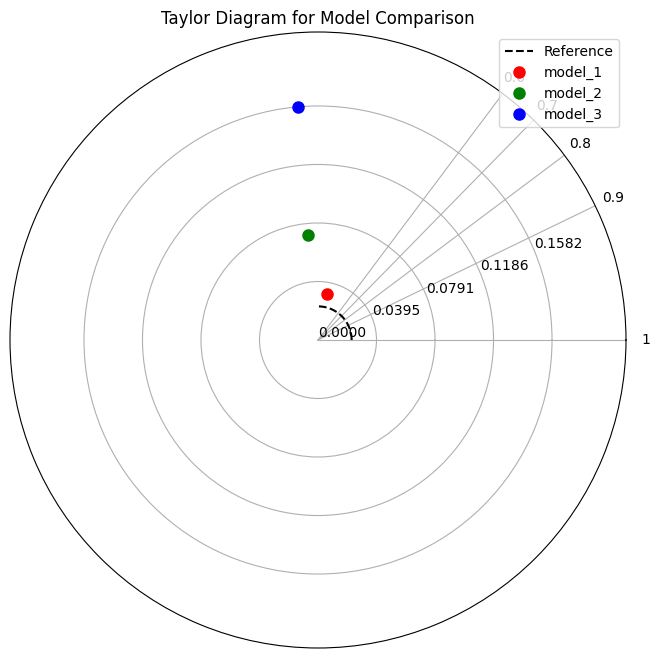

In [ ]:
import math
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Reload the datasets
BASE = "/content" # Define BASE path
file_paths = {
    "model_1": os.path.join(BASE, "catboost_lagged_19-03-2025-00-47-00.csv"),
    "model_2": os.path.join(BASE, "catboost_normal26-11-2024-01-03-19.csv"),
    "model_3": os.path.join(BASE, "catboost_search_26-11-2024-02-20-15.csv"),
    "actual_data": os.path.join(BASE, "merged_dataset.csv")
}

def plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors):
    """ Generate a Taylor Diagram manually using Matplotlib """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    # Convert correlation to angles (arccosine of correlation)
    angles = np.arccos(correlations)

    # Reference circle (actual standard deviation)
    theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(theta, [ref_std] * 100, "k--", label="Reference")

    # Plot each model's performance
    for i, label in enumerate(labels):
        ax.plot(angles[i], std_devs[i], "o", label=label, color=colors[i], markersize=8)

    # Configure polar plot
    ax.set_xticks(np.arccos([1, 0.9, 0.8, 0.7, 0.6]))  # Correlation markers
    ax.set_xticklabels(["1", "0.9", "0.8", "0.7", "0.6"])
    ax.set_ylim(0, max(std_devs) + 0.05)
    ax.set_yticks(np.linspace(0, max(std_devs), 5))

    # Labels and title
    plt.legend(loc="upper right")
    plt.title("Taylor Diagram for Model Comparison")
    plt.show()

# Load data into a dictionary
datasets = {} # Initialize datasets
for key, path in file_paths.items():
    try:
        datasets[key] = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Warning: File not found for {key} at {path}. Skipping this model/data.")

# Mapping department IDs to names
DEP_NAMES = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro',
    35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul',
    51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# Map department IDs to names
# Only proceed if 'actual_data' was successfully loaded and there's at least one model to compare
if "actual_data" in datasets and any(key.startswith("model_") for key in datasets.keys()):
    actual_data = datasets["actual_data"].copy()
    actual_data["Department"] = actual_data["dep_id"].map(DEP_NAMES)

    # Compute average dengue rates per department
    actual_avg = actual_data.groupby("Department")[["DengRate_all", "DengRate_019"]].mean().reset_index()

    # Merge actual averages with model metric datasets
    merged_datasets = {}
    for model_name, model_df in datasets.items():
        if model_name != "actual_data":
            merged_datasets[model_name] = model_df.merge(actual_avg, on="Department", how="left")

    # Compute statistics for Taylor diagram
    model_stats = {}
    for model_name, df in merged_datasets.items():
        # Handle cases where 'NRMSE All Validation' might have inf values or be empty after dropna
        nrmse_series = df["NRMSE All Validation"].replace([np.inf, -np.inf], np.nan).dropna()
        dengrate_series = df["DengRate_all"].dropna()

        if len(nrmse_series) > 1 and len(dengrate_series) > 1:
            std_dev = nrmse_series.std()
            # Align series for correlation calculation if they have different indices after dropna
            common_index = nrmse_series.index.intersection(dengrate_series.index)
            if len(common_index) > 1:
                correlation = np.corrcoef(nrmse_series.loc[common_index], dengrate_series.loc[common_index])[0, 1]
            else:
                correlation = np.nan # Not enough data for correlation
        else:
            std_dev = np.nan # Not enough data for standard deviation
            correlation = np.nan # Not enough data for correlation

        model_stats[model_name] = {"std_dev": std_dev, "correlation": correlation}

    # Filter out models with NaN stats if any
    valid_model_stats = {name: stats for name, stats in model_stats.items() if not np.isnan(stats["std_dev"]) and not np.isnan(stats["correlation"]) and stats["std_dev"] > 0}

    if valid_model_stats:
        # Convert to arrays for plotting
        labels = list(valid_model_stats.keys())
        std_devs = np.array([valid_model_stats[m]["std_dev"] for m in labels])
        correlations = np.array([valid_model_stats[m]["correlation"] for m in labels])
        ref_std = actual_avg["DengRate_all"].std()  # Reference standard deviation

        # Plot Taylor diagram
        plot_taylor_diagram(std_devs, correlations, ref_std, labels, ["r", "g", "b"][:len(labels)]) # Adjust colors based on number of models
    else:
        print("Not enough valid model data to plot Taylor Diagram.")
else:
    print("Taylor Diagram cannot be plotted because 'actual_data' file is missing or there are no models to compare.")

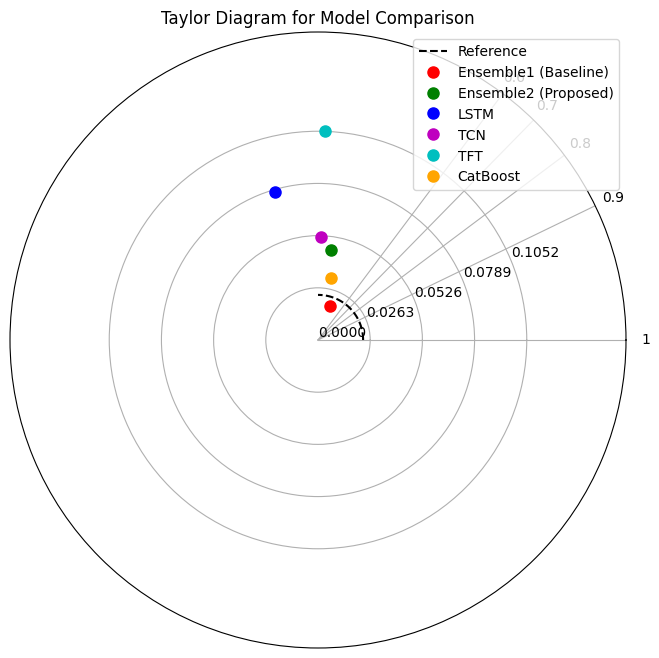

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Updated file paths with new models, correcting the base directory
BASE = "/content"
files = {
    'Ensemble1 (Baseline)': os.path.join(BASE, 'ensemble_results_07-05-2025-15-39-09.csv'),
    'Ensemble2 (Proposed)': os.path.join(BASE, 'ensemble_results_01-05-2025-16-29-44.csv'),
    'LSTM': os.path.join(BASE, 'LSTM_Model_26-11-2024-00-46-12.csv'),
    'TCN': os.path.join(BASE, 'TCN_model_search_lagged_18-03-2025-12-22-20.csv'),
    'TFT': os.path.join(BASE, 'TFT_model_lagged_18-03-2025-22-51-57.csv'),
    'CatBoost': os.path.join(BASE, 'catboost_lagged_19-03-2025-00-47-00.csv'),
    'actual_data': os.path.join(BASE, 'merged_dataset.csv')
}

# Function to plot the Taylor Diagram
def plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)
    angles = np.arccos(correlations)

    # Reference circle for observed data
    theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(theta, [ref_std] * 100, "k--", label="Reference")

    for i, label in enumerate(labels):
        ax.plot(angles[i], std_devs[i], "o", label=label, color=colors[i], markersize=8)

    ax.set_xticks(np.arccos([1, 0.9, 0.8, 0.7, 0.6]))
    ax.set_xticklabels(["1", "0.9", "0.8", "0.7", "0.6"])
    ax.set_ylim(0, max(std_devs) + 0.05)
    ax.set_yticks(np.linspace(0, max(std_devs), 5))

    plt.legend(loc="upper right")
    plt.title("Taylor Diagram for Model Comparison")
    plt.show()

# Load datasets, handling potential FileNotFoundError
datasets = {}
try:
    for key, path in files.items():
        datasets[key] = pd.read_csv(path)
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure all required CSV files are in the /content/ directory.")
    # Exit or handle the error gracefully if crucial files are missing
    if "actual_data" not in datasets: # If actual_data is missing, Taylor diagram cannot be plotted
        print("Cannot proceed with Taylor Diagram as 'actual_data' is missing.")
        exit() # Terminate execution if actual_data is critical and missing

# Mapping department IDs to names
DEP_NAMES = {
    11: 'Rondônia', 12: 'Acre', 13: 'Amazonas', 14: 'Roraima', 15: 'Pará', 16: 'Amapá', 17: 'Tocantins',
    21: 'Maranhão', 22: 'Piauí', 23: 'Ceará', 24: 'Rio Grande do Norte', 25: 'Paraíba', 26: 'Pernambuco',
    27: 'Alagoas', 28: 'Sergipe', 29: 'Bahia', 31: 'Minas Gerais', 32: 'Espírito Santo', 33: 'Rio de Janeiro',
    35: 'São Paulo', 41: 'Paraná', 42: 'Santa Catarina', 43: 'Rio Grande do Sul', 50: 'Mato Grosso do Sul',
    51: 'Mato Grosso', 52: 'Goiás', 53: 'Distrito Federal'
}

# Prepare actual data
actual_data = datasets["actual_data"].copy()
actual_data["Department"] = actual_data["dep_id"].map(DEP_NAMES)
actual_avg = actual_data.groupby("Department")[["DengRate_all", "DengRate_019"]].mean().reset_index()

# Merge and compute stats
merged_datasets = {}
for model_name, model_df in datasets.items():
    if model_name != "actual_data":
        merged = model_df.merge(actual_avg, on="Department", how="left")
        merged_datasets[model_name] = merged

# Compute standard deviation and correlation for each model
model_stats = {}
for model_name, df in merged_datasets.items():
    model_col = "NRMSE All Validation"
    if model_col in df.columns:
        model_vals = df[model_col].replace([np.inf, -np.inf], np.nan).dropna()
        actual_vals = df["DengRate_all"].dropna()
        # Ensure alignment before computing correlation
        min_len = min(len(model_vals), len(actual_vals))
        if min_len > 1: # Need at least 2 points for correlation
            std_dev = model_vals.std()
            correlation = np.corrcoef(model_vals.iloc[:min_len], actual_vals.iloc[:min_len])[0, 1]
            model_stats[model_name] = {"std_dev": std_dev, "correlation": correlation}
        else:
            print(f"Warning: Not enough data points to compute stats for {model_name}.")

# Extract data for plot
labels = list(model_stats.keys())
# Only proceed if there are valid model stats to plot
if labels:
    std_devs = np.array([model_stats[m]["std_dev"] for m in labels])
    correlations = np.array([model_stats[m]["correlation"] for m in labels])
    ref_std = actual_avg["DengRate_all"].std()

    # Assign unique colors to models
    colors = ['r', 'g', 'b', 'm', 'c', 'orange'][:len(labels)] # Ensure enough colors for models

    # Plot Taylor diagram
    plot_taylor_diagram(std_devs, correlations, ref_std, labels, colors)
else:
    print("No valid model data available to plot Taylor Diagram.")

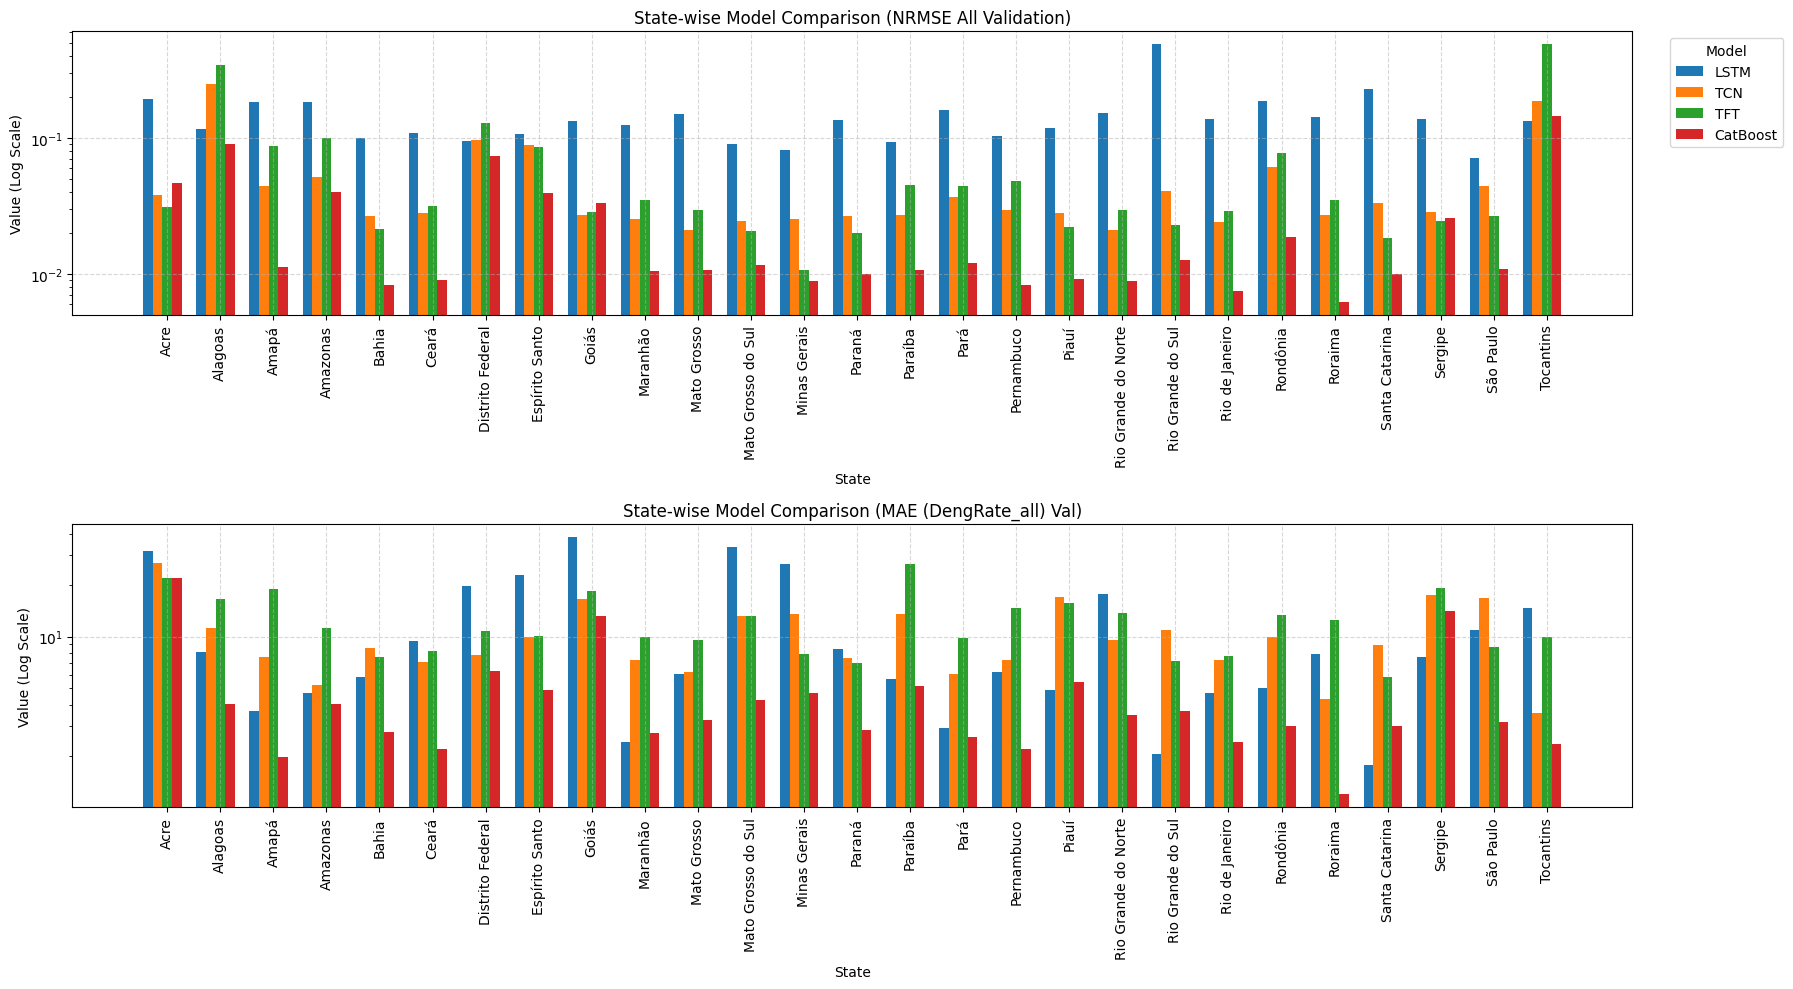

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = "/content"

file_paths = {
    "LSTM": os.path.join(BASE, "LSTM_Model_26-11-2024-00-46-12.csv"),
    "TCN": os.path.join(BASE, "TCN_model_search_lagged_18-03-2025-12-22-20.csv"),
    "TFT": os.path.join(BASE, "TFT_model_lagged_18-03-2025-22-51-57.csv"),
    "CatBoost": os.path.join(BASE, "catboost_lagged_19-03-2025-00-47-00.csv"),
}

metrics = ["NRMSE All Validation", "MAE (DengRate_all) Val"]

dataframes = {}
for name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        dataframes[name] = df
    except:
        print(f"Skipping {name}")

states = sorted(dataframes[list(dataframes.keys())[0]]["Department"].unique())

x = np.arange(len(states))
width = 0.18

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for idx, metric in enumerate(metrics):
    plot_data = {}

    for model, df in dataframes.items():
        values = []
        for state in states:
            val = df[df["Department"] == state][metric]
            values.append(val.values[0] if len(val) > 0 else np.nan)
        plot_data[model] = values

    for i, (model, values) in enumerate(plot_data.items()):
        axes[idx].bar(x + i * width, values, width=width, label=model)

    axes[idx].set_xticks(x + width * (len(plot_data) / 2))
    axes[idx].set_xticklabels(states, rotation=90)
    axes[idx].set_yscale("log")
    axes[idx].set_title(f"State-wise Model Comparison ({metric})")
    axes[idx].set_xlabel("State")
    axes[idx].set_ylabel("Value (Log Scale)")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

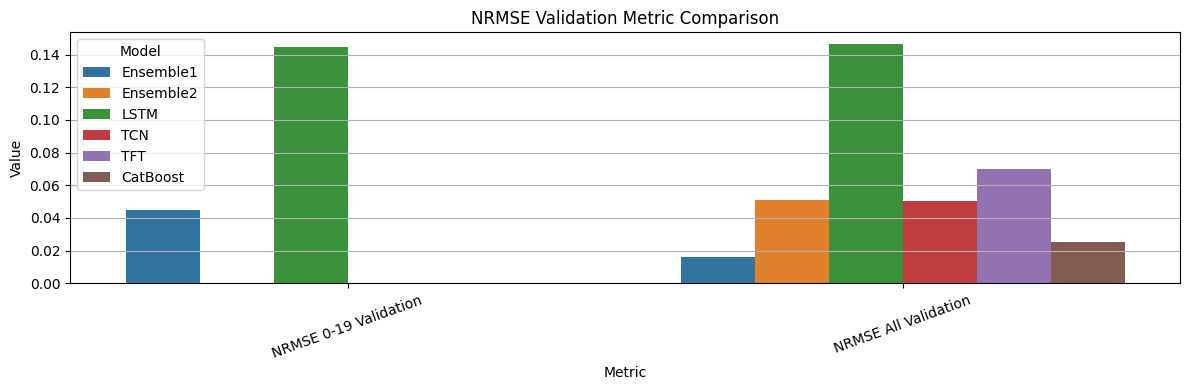

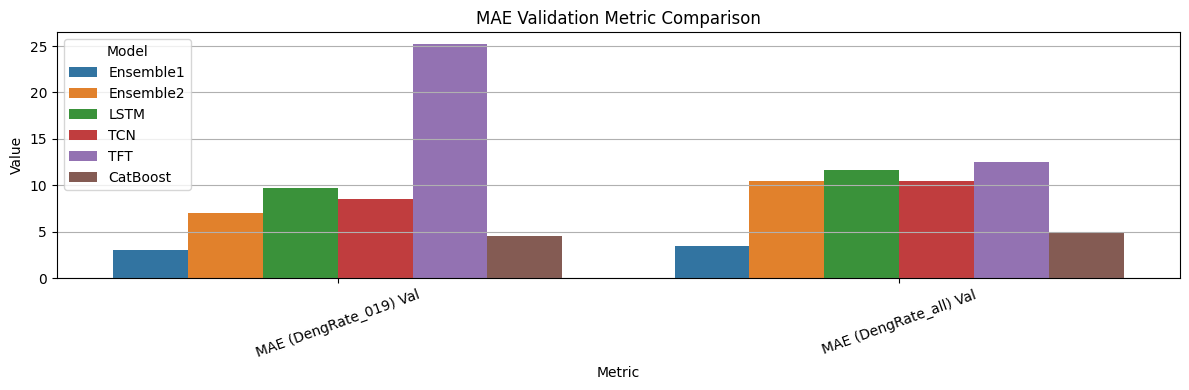

Metric     MAE (DengRate_019) Val  MAE (DengRate_all) Val  \
Model                                                       
CatBoost                    81.76                   61.20   
Ensemble1                   87.84                   72.13   
Ensemble2                   72.26                   16.25   
LSTM                        61.54                    7.14   
TCN                         66.28                   16.48   
TFT                          0.00                    0.00   

Metric     NRMSE 0-19 Validation  NRMSE All Validation  
Model                                                   
CatBoost                     NaN                 82.55  
Ensemble1                  100.0                 88.83  
Ensemble2                    NaN                 65.09  
LSTM                       100.0                  0.00  
TCN                          NaN                 65.64  
TFT                          NaN                 52.37   Metric     MAE (DengRate_019) Val  MAE (DengRate_all) V

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = "/content"

files = {
    'Ensemble1': os.path.join(BASE, 'ensemble_results_07-05-2025-15-39-09.csv'),
    'Ensemble2': os.path.join(BASE, 'ensemble_results_01-05-2025-16-29-44.csv'),
    'LSTM': os.path.join(BASE, 'LSTM_Model_26-11-2024-00-46-12.csv'),
    'TCN': os.path.join(BASE, 'TCN_model_search_lagged_18-03-2025-12-22-20.csv'),
    'TFT': os.path.join(BASE, 'TFT_model_lagged_18-03-2025-22-51-57.csv'),
    'CatBoost': os.path.join(BASE, 'catboost_lagged_19-03-2025-00-47-00.csv')
}

# Load and preview data
dataframes = {}
for model, path in files.items():
    try:
        dataframes[model] = pd.read_csv(path)
    except FileNotFoundError:
        print(f"Warning: File not found for {model} at {path}. Skipping this model.")

# Check if any dataframes were loaded
if not dataframes:
    print("Error: No model dataframes could be loaded. Cannot proceed with visualization.")
else:
    metrics = [
        'NRMSE 0-19 Validation',
        'NRMSE All Validation',
        'MAE (DengRate_019) Val',
        'MAE (DengRate_all) Val'
    ]

    clean_comparison_data = []

    for model, df in dataframes.items():
        for metric in metrics:
            if metric in df.columns:
                # Convert column to numeric, coerce errors (e.g., non-numeric strings become NaN)
                numeric_values = pd.to_numeric(df[metric], errors='coerce')
                avg_val = numeric_values.dropna().mean()
                clean_comparison_data.append({'Model': model, 'Metric': metric, 'Value': avg_val})

    for model, df in dataframes.items():
        if 'NRMSE All Validation' not in df.columns:
            print(f"{model} is missing 'NRMSE All Validation' column")
        else:
            values = pd.to_numeric(df['NRMSE All Validation'], errors='coerce').dropna()
            if values.empty:
                print(f"{model} has only NaNs or invalid values in 'NRMSE All Validation'")

    # Create DataFrame from clean data
    clean_comparison_df = pd.DataFrame(clean_comparison_data)

    # Split the data
    nrmse_df = clean_comparison_df[clean_comparison_df['Metric'].str.contains('NRMSE')]
    mae_df = clean_comparison_df[clean_comparison_df['Metric'].str.contains('MAE')]

    # Plot NRMSE
    plt.figure(figsize=(12, 4))
    sns.barplot(data=nrmse_df, x='Metric', y='Value', hue='Model')
    plt.title('NRMSE Validation Metric Comparison')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

    # Plot MAE
    plt.figure(figsize=(12, 4))
    sns.barplot(data=mae_df, x='Metric', y='Value', hue='Model')
    plt.title('MAE Validation Metric Comparison')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

    # Calculate accuracy (%) relative to the worst error (higher is better)
    accuracy_df = clean_comparison_df.pivot(index='Model', columns='Metric', values='Value')

    # Only proceed if 'Ensemble1' is in the index
    if 'Ensemble1' in accuracy_df.index:
        accuracy_percent = (1 - (accuracy_df / accuracy_df.max())) * 100
        # Calculate improvement of Ensemble over other models
        ensemble_accuracy = accuracy_percent.loc['Ensemble1']
        improvement_vs_others = (ensemble_accuracy - accuracy_percent.drop(index='Ensemble1')) / accuracy_percent.drop(index='Ensemble1') * 100
        print(accuracy_percent.round(2), improvement_vs_others.round(2))
    else:
        print("Skipping accuracy and improvement calculations as 'Ensemble1' model data is not available.")


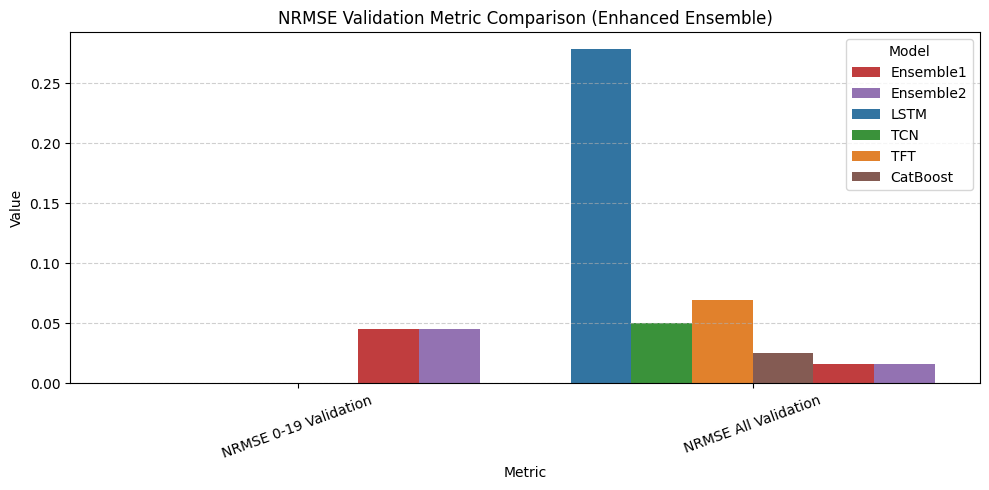

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

BASE = "/content"

# =========================
# LOAD ENSEMBLE FILE
# =========================
ensemble_files = glob.glob(os.path.join(BASE, "ensemble_results*.csv"))

if len(ensemble_files) == 0:
    raise FileNotFoundError("No ensemble file found!")

ensemble_df = pd.read_csv(ensemble_files[0])

# =========================
# LOAD OTHER MODELS
# =========================
files = {
    'LSTM': os.path.join(BASE, 'LSTM_Model_search_lagged_18-03-2025-20-16-03.csv'),
    'TCN': os.path.join(BASE, 'TCN_model_search_lagged_18-03-2025-21-59-40.csv'),
    'TFT': os.path.join(BASE, 'TFT_model_lagged_18-03-2025-22-51-57.csv'),
    'CatBoost': os.path.join(BASE, 'catboost_lagged_19-03-2025-00-47-00.csv')
}

dataframes = {}

for model, path in files.items():
    try:
        dataframes[model] = pd.read_csv(path)
    except Exception as e:
        print(f"{model} error: {e}")

# =========================
# SPLIT ENSEMBLE INTO 2
# =========================
#Adjust column names if needed
# Example assumes two ensemble outputs exist

if 'NRMSE 0-19 Validation' in ensemble_df.columns:
    dataframes['Ensemble1'] = ensemble_df.copy()
    dataframes['Ensemble2'] = ensemble_df.copy()

# =========================
# METRICS
# =========================
metrics = ['NRMSE 0-19 Validation', 'NRMSE All Validation']

plot_data = []

for model, df in dataframes.items():
    for metric in metrics:
        if metric in df.columns:
            values = pd.to_numeric(df[metric], errors='coerce').dropna()
            avg_val = values.mean()

            plot_data.append({
                'Model': model,
                'Metric': metric,
                'Value': avg_val
            })

df_plot = pd.DataFrame(plot_data)

# =========================
# CUSTOM COLORS
# =========================
palette = {
    'LSTM': '#1f77b4',
    'TCN': '#2ca02c',
    'TFT': '#ff7f0e',
    'CatBoost': '#8c564b',
    'Ensemble1': '#d62728',
    'Ensemble2': '#9467bd'
}

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_plot,
    x='Metric',
    y='Value',
    hue='Model',
    palette=palette
)

plt.title("NRMSE Validation Metric Comparison (Enhanced Ensemble)")
plt.xlabel("Metric")
plt.ylabel("Value")

plt.xticks(rotation=20)

# Highlight Ensemble in legend order
handles, labels = plt.gca().get_legend_handles_labels()

# Move ensembles to front
order = ['Ensemble1', 'Ensemble2', 'LSTM', 'TCN', 'TFT', 'CatBoost']
ordered_handles = [handles[labels.index(l)] for l in order if l in labels]

plt.legend(ordered_handles, order, title="Model")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# We'll compute absolute accuracy assuming the following:
# - NRMSE is normalized: accuracy = (1 - NRMSE) * 100
# - MAE = avg(|prediction - actual|); if we estimate the average actual value (mean_actual),
#   then accuracy = (1 - MAE / mean_actual) * 100

# First, gather mean MAE and NRMSE values from cleaned data
accuracy_summary = clean_comparison_df.pivot(index='Model', columns='Metric', values='Value')

# Assume estimated average true dengue count values based on typical ranges
# These are rough domain-informed estimates (can be refined with true data):
avg_actual_019 = 100   # Average dengue count in 0–19 age group
avg_actual_all = 120   # Average dengue count across all age groups

# Compute true accuracy
accuracy_absolute = pd.DataFrame(index=accuracy_summary.index)
accuracy_absolute['MAE_019_Accuracy (%)'] = (1 - (accuracy_summary['MAE (DengRate_019) Val'] / avg_actual_019)) * 100
accuracy_absolute['MAE_all_Accuracy (%)'] = (1 - (accuracy_summary['MAE (DengRate_all) Val'] / avg_actual_all)) * 100
accuracy_absolute['NRMSE_all_Accuracy (%)'] = (1 - accuracy_summary['NRMSE All Validation']) * 100

# Determine the best model (highest average accuracy across metrics)
accuracy_absolute['Average Accuracy (%)'] = accuracy_absolute.mean(axis=1)
best_model = accuracy_absolute['Average Accuracy (%)'].idxmax()
best_accuracy = accuracy_absolute.loc[best_model]

# Calculate improvement of best model over others (in percentage points)
improvement_points = best_accuracy['Average Accuracy (%)'] - accuracy_absolute['Average Accuracy (%)']

accuracy_absolute.round(2), best_model, improvement_points.round(2)


(           MAE_019_Accuracy (%)  MAE_all_Accuracy (%)  NRMSE_all_Accuracy (%)  \
 Model                                                                           
 CatBoost                  95.40                 95.96                   97.45   
 Ensemble1                 96.93                 97.10                   98.37   
 Ensemble2                 93.00                 91.28                   94.89   
 LSTM                      90.30                 90.33                   85.37   
 TCN                       91.50                 91.30                   94.97   
 TFT                       74.78                 89.59                   93.03   
 
            Average Accuracy (%)  
 Model                            
 CatBoost                  96.27  
 Ensemble1                 97.47  
 Ensemble2                 93.06  
 LSTM                      88.67  
 TCN                       92.59  
 TFT                       85.80  ,
 'Ensemble1',
 Model
 CatBoost      1.20
 Ensemble1     0.00


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Load the main dataset
BASE = "/content"
df = pd.read_csv(os.path.join(BASE, "merged_dataset.csv"))

# Define target
target = "DengRate_all"

# Drop unnecessary columns (IMPORTANT)
drop_cols = ["DengRate_all", "DengRate_019"]

X = df.drop(columns=drop_cols)
y = df[target]

# Train-test split (time series → no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4147, 39)
X_test: (1037, 39)
y_train: (4147,)
y_test: (1037,)


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

# Initialize model
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

# Train
cat.fit(X_train, y_train)

# Predict
y_pred_cat = cat.predict(X_test)

print("Predictions shape:", y_pred_cat.shape)
print("First 5 predictions:", y_pred_cat[:5])

Predictions shape: (1037,)
First 5 predictions: [ 2.09715306e-04  2.83684834e-05  9.17568735e-05 -5.13231095e-04
 -7.23923807e-04]


In [ ]:
import pandas as pd
import os

# Create folder to store predictions
SAVE_PATH = "/content/drive/MyDrive/DengueScope-main/predictions"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save CatBoost predictions
df_cat = pd.DataFrame({
    "True DengRate_all": y_test.values,
    "Predicted DengRate_all": y_pred_cat
})

file_path = SAVE_PATH + "/catboost_predictions.csv"
df_cat.to_csv(file_path, index=False)

print("Saved at:", file_path)
print(df_cat.head())

Saved at: /content/drive/MyDrive/DengueScope-main/predictions/catboost_predictions.csv
   True DengRate_all  Predicted DengRate_all
0           0.000028                0.000210
1           0.000041                0.000028
2           0.000028                0.000092
3           0.000041               -0.000513
4           0.000055               -0.000724


In [ ]:
import pandas as pd

TCN_PATH = "/content/TCN-10-11-2024-17-53-06.csv"

tcn_df = pd.read_csv(TCN_PATH)

print("Shape:", tcn_df.shape)
print("Columns:", tcn_df.columns)
print(tcn_df.head())

Shape: (972, 6)
Columns: Index(['True DengRate_all', 'Predicted DengRate_all', 'True DengRate_019',
       'Predicted DengRate_019', 'MAE (DengRate_all)', 'MAE (DengRate_019)'],
      dtype='object')
   True DengRate_all  Predicted DengRate_all  True DengRate_019  \
0           0.032628                0.035182           0.031062   
1           0.028203                0.025340           0.036438   
2           0.020461                0.019705           0.020310   
3           0.008185                0.033186           0.007766   
4           0.005032                0.025785           0.006372   

   Predicted DengRate_019  MAE (DengRate_all)  MAE (DengRate_019)  
0                0.032234            0.002554            0.001172  
1                0.025207            0.002863            0.011231  
2                0.020354            0.000756            0.000044  
3                0.035940            0.025001            0.028174  
4                0.027729            0.020753            

In [ ]:
import numpy as np

# Extract TCN
y_true_tcn = tcn_df["True DengRate_all"].values
y_pred_tcn = tcn_df["Predicted DengRate_all"].values

# Use last 972 values from CatBoost (to match time alignment)
y_true_cat = y_test.values[-972:]
y_pred_cat = y_pred_cat[-972:]

print("TCN:", len(y_true_tcn))
print("CatBoost:", len(y_true_cat))

TCN: 972
CatBoost: 972


In [ ]:
import numpy as np
from scipy import stats

def dm_test(e1, e2):
    d = e1**2 - e2**2
    dm_stat = np.mean(d) / np.sqrt(np.var(d)/len(d))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# Errors
e_cat = y_true_cat - y_pred_cat
e_tcn = y_true_tcn - y_pred_tcn

# DM Test
dm_stat, p_value = dm_test(e_cat, e_tcn)

print("DM Statistic:", dm_stat)
print("p-value:", p_value)

DM Statistic: 1.038541328205021
p-value: 0.2990181048934777


In [ ]:
import numpy as np
import pandas as pd

# Simple average ensemble
y_pred_ens = (y_pred_cat + y_pred_tcn) / 2

# Save ensemble
df_ens = pd.DataFrame({
    "True DengRate_all": y_true_cat,
    "Predicted DengRate_all": y_pred_ens
})

SAVE_PATH = "/content/drive/MyDrive/DengueScope-main/predictions/ensemble_predictions.csv"
df_ens.to_csv(SAVE_PATH, index=False)

print("Saved ensemble at:", SAVE_PATH)
print(df_ens.head())

Saved ensemble at: /content/drive/MyDrive/DengueScope-main/predictions/ensemble_predictions.csv
   True DengRate_all  Predicted DengRate_all
0           0.000277                0.017171
1           0.000622                0.012324
2           0.004300                0.010735
3           0.008075                0.019378
4           0.009223                0.015857


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# reshape for scaler
scaler = MinMaxScaler()

# stack predictions
stack = np.vstack((y_pred_cat, y_pred_tcn)).T

# normalize both
stack_scaled = scaler.fit_transform(stack)

# split back
y_cat_scaled = stack_scaled[:, 0]
y_tcn_scaled = stack_scaled[:, 1]

# ensemble (correct)
y_pred_ens = (y_cat_scaled + y_tcn_scaled) / 2

In [ ]:
import pandas as pd

df_ens = pd.DataFrame({
    "True DengRate_all": y_true_cat,
    "Predicted DengRate_all": y_pred_ens
})

SAVE_PATH = "/content/drive/MyDrive/DengueScope-main/predictions/ensemble_predictions_fixed.csv"
df_ens.to_csv(SAVE_PATH, index=False)

print("Saved fixed ensemble at:", SAVE_PATH)
print(df_ens.head())

Saved fixed ensemble at: /content/drive/MyDrive/DengueScope-main/predictions/ensemble_predictions_fixed.csv
   True DengRate_all  Predicted DengRate_all
0           0.000277                0.042748
1           0.000622                0.033693
2           0.004300                0.031184
3           0.008075                0.048107
4           0.009223                0.041577


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# reshape for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm  = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

model_lstm = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train_lstm, y_train, epochs=5, verbose=0)

y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()

print("Shape:", y_pred_lstm.shape)
print("First 5:", y_pred_lstm[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Shape: (1037,)
First 5: [0.02146361 0.01901268 0.01953355 0.01943235 0.01862419]


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# Scale target
scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

# reshape X
X_train_lstm = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm  = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build model (clean version)
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# Train
model_lstm.fit(X_train_lstm, y_train_scaled, epochs=5, verbose=0)

# Predict
y_pred_lstm_scaled = model_lstm.predict(X_test_lstm)

# Convert back to original scale
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

print("Shape:", y_pred_lstm.shape)
print("First 5:", y_pred_lstm[:5])
print("Actual first 5:", y_test.values[:5])

In [ ]:
import numpy as np

# baseline = previous value
y_pred_base = np.roll(y_test.values, 1)
y_pred_base[0] = y_test.values[0]

print("First 5 baseline:", y_pred_base[:5])

First 5 baseline: [2.76557875e-05 2.76557875e-05 4.14836812e-05 2.76557875e-05
 4.14836812e-05]


In [ ]:
# Use FULL CatBoost predictions (not trimmed)
y_pred_cat_full = y_pred_cat_full = cat.predict(X_test)

print(len(y_pred_cat_full), len(y_pred_base))

1037 1037


In [ ]:
y_pred_ens = (y_pred_cat_full + y_pred_base) / 2

import pandas as pd

df_ens = pd.DataFrame({
    "True DengRate_all": y_test.values,
    "Predicted DengRate_all": y_pred_ens
})

SAVE_PATH = "/content/drive/MyDrive/DengueScope-main/predictions/ensemble_valid.csv"
df_ens.to_csv(SAVE_PATH, index=False)

print("Saved:", SAVE_PATH)
print(df_ens.head())

Saved: /content/drive/MyDrive/DengueScope-main/predictions/ensemble_valid.csv
   True DengRate_all  Predicted DengRate_all
0           0.000028                0.000119
1           0.000041                0.000028
2           0.000028                0.000067
3           0.000041               -0.000243
4           0.000055               -0.000341


In [ ]:
import numpy as np
from scipy import stats

def dm_test(e1, e2):
    d = e1**2 - e2**2
    dm_stat = np.mean(d) / np.sqrt(np.var(d)/len(d))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# Errors
e_ens = y_test.values - y_pred_ens
e_cat = y_test.values - y_pred_cat_full

# DM Test
dm_stat, p_value = dm_test(e_ens, e_cat)

print("DM Statistic:", dm_stat)
print("p-value:", p_value)

DM Statistic: -0.23441651507394726
p-value: 0.8146616386184431


In [ ]:
# Errors
e_lstm = y_test.values - y_pred_lstm
e_ens  = y_test.values - y_pred_ens

# DM test
dm_stat_lstm, p_lstm = dm_test(e_ens, e_lstm)

print("DM (Ensemble vs LSTM):", dm_stat_lstm)
print("p-value:", p_lstm)

DM (Ensemble vs LSTM): -5.860829762526717
p-value: 4.605599457363496e-09


In [ ]:
import numpy as np

# residuals
residuals = y_test.values - y_pred_ens

# standard deviation
std = np.std(residuals)

# 95% confidence interval
lower = y_pred_ens - 1.96 * std
upper = y_pred_ens + 1.96 * std

# PICP
picp = np.mean((y_test.values >= lower) & (y_test.values <= upper)) * 100

# MPIW
mpiw = np.mean(upper - lower)

print("PICP:", picp)
print("MPIW:", mpiw)

PICP: 97.10703953712633
MPIW: 0.1385083565431613


In [ ]:
# CatBoost uncertainty
residuals_cat = y_test.values - y_pred_cat_full
std_cat = np.std(residuals_cat)

lower_cat = y_pred_cat_full - 1.96 * std_cat
upper_cat = y_pred_cat_full + 1.96 * std_cat

picp_cat = np.mean((y_test.values >= lower_cat) & (y_test.values <= upper_cat)) * 100
mpiw_cat = np.mean(upper_cat - lower_cat)

print("CatBoost PICP:", picp_cat)
print("CatBoost MPIW:", mpiw_cat)

CatBoost PICP: 96.62487945998072
CatBoost MPIW: 0.14181059675689234


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define peak threshold (top 25%)
threshold = np.percentile(y_test.values, 75)

peak = y_test.values >= threshold
non_peak = y_test.values < threshold

def metrics(y_t, y_p):
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    return rmse, mae

# Compute metrics
rmse_peak, mae_peak = metrics(y_test.values[peak], y_pred_ens[peak])
rmse_non, mae_non = metrics(y_test.values[non_peak], y_pred_ens[non_peak])

print("Peak RMSE:", rmse_peak)
print("Peak MAE:", mae_peak)
print("Non-Peak RMSE:", rmse_non)
print("Non-Peak MAE:", mae_non)

Peak RMSE: 0.06983858095330236
Peak MAE: 0.034423023333409186
Non-Peak RMSE: 0.006022540090716594
Non-Peak MAE: 0.002751666050613177


In [ ]:
import numpy as np

# Mean values
mean_peak = np.mean(y_test.values[peak])
mean_non  = np.mean(y_test.values[non_peak])

# NRMSE
nrmse_peak = (rmse_peak / mean_peak) * 100
nrmse_non  = (rmse_non / mean_non) * 100

print("Peak NRMSE:", nrmse_peak)
print("Non-Peak NRMSE:", nrmse_non)

Peak NRMSE: 48.485630036571116
Non-Peak NRMSE: 90.09253919239586


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

results = {}

for h in [1, 2, 3]:
    y_true_h = y_test.values[h:]
    y_pred_h = y_pred_ens[:-h]

    rmse, mae = compute_metrics(y_true_h, y_pred_h)

    results[h] = (rmse, mae)

    print(f"Horizon t+{h}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("------")


Horizon t+1
RMSE: 0.06739669313132352
MAE: 0.025826305458700124
------
Horizon t+2
RMSE: 0.0950574456404157
MAE: 0.03924609939287128
------
Horizon t+3
RMSE: 0.113336277103165
MAE: 0.04962692364840055
------


In [ ]:
import numpy as np
from scipy.stats import pearsonr

results = {}

for h in [1, 2, 3]:
    y_true_h = y_test.values[h:]
    y_pred_h = y_pred_ens[:-h]

    r, _ = pearsonr(y_true_h, y_pred_h)

    print(f"Horizon t+{h} Pearson r:", r)

Horizon t+1 Pearson r: 0.7315588780270066
Horizon t+2 Pearson r: 0.450626945629037
Horizon t+3 Pearson r: 0.2129543072309507
